# NLP Model Benchmark — AG News
## Attention Mechanism, Custom Transformer, BERT, BART, GPT-2 and T5

This corrected notebook is based on the uploaded project.

### Main fixes
- Uses the current Hugging Face `Trainer` API: `processing_class=tokenizer`
- Handles BART/GPT prediction outputs safely when `Trainer.predict()` returns a tuple
- Configures 4 AG News labels explicitly
- Gives GPT-2 a valid `pad_token`
- Uses a dedicated `Seq2SeqTrainer` pipeline for T5 instead of treating T5 as a normal sequence-classification model
- Saves every successfully trained model independently, so one missing model variable cannot stop the save cell
- Keeps test probabilities for ROC/AUC where the model naturally produces class probabilities
- Removes the Keras attention masking warning by applying the mask inside the custom attention layer

In [1]:
# ============================================================
# 0. Install / upgrade dependencies
# ============================================================
# Run this cell once in a fresh Colab/Kaggle environment.
# After installation, restart the runtime if the notebook asks you to.

#!pip -q install -U "transformers>=4.45" "datasets>=2.20" "accelerate>=0.34"     scikit-learn pandas numpy matplotlib seaborn sentencepiece

In [2]:
# ============================================================
# 1. Imports and configuration
# ============================================================
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from datasets import load_dataset, Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    AutoConfig,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq,
    T5Tokenizer,
    T5ForConditionalGeneration,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

TRAIN_SAMPLES = 7000
VAL_SAMPLES = 1000
TEST_SAMPLES = 2000

MAX_LEN = 128
BATCH_SIZE = 16
EPOCHS = 1
LEARNING_RATE = 2e-5

LABEL_NAMES = ["World", "Sports", "Business", "Sci/Tech"]
LABEL_WORDS = {
    0: "world",
    1: "sports",
    2: "business",
    3: "sci_tech",
}
LABEL2ID = {v: k for k, v in enumerate(LABEL_NAMES)}
NUM_LABELS = 4

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("PyTorch device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
print("TensorFlow GPUs:", tf.config.list_physical_devices("GPU"))

PyTorch device: cuda
GPU: Tesla T4
TensorFlow GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Load AG News from Hugging Face

The original notebook used the public `xwjzds/ag_news` repository because the short `ag_news` identifier was producing an HF URI error in the user's environment.

In [3]:
# ============================================================
# 2. Load dataset
# ============================================================
dataset = load_dataset("xwjzds/ag_news")

print(dataset)
print(dataset["train"][0])

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})
{'text': "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.", 'label': 2}


In [4]:
# ============================================================
# 3. Build stratified train / validation / test dataframes
# ============================================================
train_full = dataset["train"].shuffle(seed=SEED)
test_full = dataset["test"].shuffle(seed=SEED)

train_n = min(TRAIN_SAMPLES, len(train_full))
test_n = min(TEST_SAMPLES, len(test_full))

train_df = pd.DataFrame(train_full.select(range(train_n)))
test_df = pd.DataFrame(test_full.select(range(test_n)))

train_df, val_df = train_test_split(
    train_df,
    test_size=min(VAL_SAMPLES, max(1, len(train_df) // 5)),
    stratify=train_df["label"],
    random_state=SEED,
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)
print("\nTrain class distribution:")
print(train_df["label"].value_counts().sort_index())

Train: (6000, 2)
Validation: (1000, 2)
Test: (2000, 2)

Train class distribution:
label
0    1532
1    1509
2    1406
3    1553
Name: count, dtype: int64


In [5]:
# ============================================================
# 4. Evaluation utilities
# ============================================================
results = []
probabilities = {}

def evaluate_predictions(y_true, y_pred, y_prob=None, model_name="Model"):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0,
    )

    result = {
        "model": model_name,
        "accuracy": float(acc),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "auc_ovr": np.nan,
    }

    if y_prob is not None:
        y_prob = np.asarray(y_prob)
        try:
            result["auc_ovr"] = float(
                roc_auc_score(
                    y_true,
                    y_prob,
                    multi_class="ovr",
                    average="weighted",
                )
            )
        except Exception as e:
            print("AUC could not be calculated:", e)

    print(f"\n===== {model_name} =====")
    print(
        classification_report(
            y_true,
            y_pred,
            target_names=LABEL_NAMES,
            zero_division=0,
        )
    )
    print("Metrics:", result)
    return result


def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(7, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=LABEL_NAMES,
        yticklabels=LABEL_NAMES,
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_multiclass_roc(y_true, y_prob, title):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)

    y_true_oh = tf.keras.utils.to_categorical(y_true, NUM_LABELS)

    plt.figure(figsize=(8, 6))

    for i, name in enumerate(LABEL_NAMES):
        fpr, tpr, _ = roc_curve(
            y_true_oh[:, i],
            y_prob[:, i],
        )
        auc_i = roc_auc_score(
            y_true_oh[:, i],
            y_prob[:, i],
        )
        plt.plot(
            fpr,
            tpr,
            label=f"{name} (AUC={auc_i:.3f})",
        )

    plt.plot([0, 1], [0, 1], "--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

# 3. Custom Attention — BiLSTM + Additive Attention

The attention mask is created from the original token IDs and applied manually inside the attention layer. This avoids the previous Keras warning about `AdditiveAttention` destroying the mask.

/usr/local/lib/python3.13/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'additive_attention_fixed' (of type AdditiveAttentionFixed) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


94/94 ━━━━━━━━━━━━━━━━━━━━ 25s 43ms/step - accuracy: 0.6952 - loss: 0.7929 - val_accuracy: 0.8610 - val_loss: 0.4265
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step

===== BiLSTM + Attention =====
              precision    recall  f1-score   support

       World       0.93      0.78      0.85       497
      Sports       0.89      0.95      0.92       483
    Business       0.83      0.78      0.80       522
    Sci/Tech       0.75      0.86      0.80       498

    accuracy                           0.84      2000
   macro avg       0.85      0.84      0.84      2000
weighted avg       0.85      0.84      0.84      2000

Metrics: {'model': 'BiLSTM + Attention', 'accuracy': 0.842, 'precision': 0.8482730465556835, 'recall': 0.842, 'f1': 0.8418971822576479, 'auc_ovr': 0.9623989517790589}


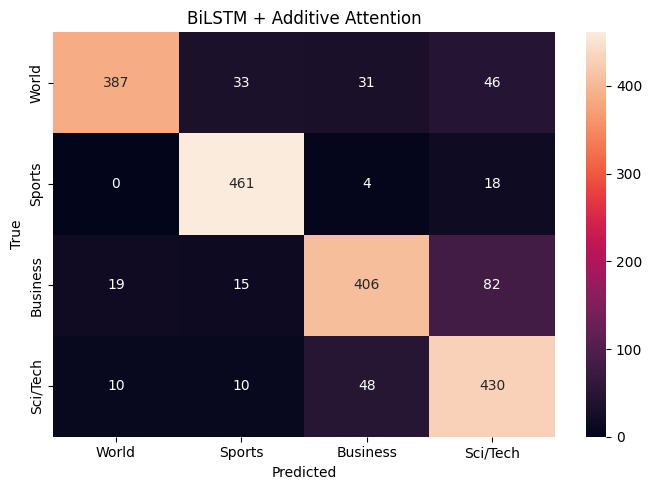

In [6]:
# ============================================================
# 5. Custom BiLSTM + Additive Attention
# ============================================================
from tensorflow.keras import layers, Model

vectorizer = layers.TextVectorization(
    max_tokens=20000,
    output_mode="int",
    output_sequence_length=MAX_LEN,
)
vectorizer.adapt(train_df["text"].values)

VOCAB_SIZE = len(vectorizer.get_vocabulary())

class AdditiveAttentionFixed(layers.Layer):
    def __init__(self, units=128):
        super().__init__()
        self.W = layers.Dense(units)
        self.U = layers.Dense(units)
        self.V = layers.Dense(1)

    def call(self, query, values, mask=None):
        score = self.V(
            tf.nn.tanh(
                self.W(query) + self.U(values)
            )
        )

        if mask is not None:
            mask = tf.cast(mask[:, :, None], tf.float32)
            score = score + (1.0 - mask) * (-1e9)

        weights = tf.nn.softmax(score, axis=1)
        context = tf.reduce_sum(weights * values, axis=1)

        return context, tf.squeeze(weights, axis=-1)


class AttentionClassifier(Model):
    def __init__(self, vocab_size, num_classes=4):
        super().__init__()

        # mask_zero=False because we apply the attention mask explicitly
        self.embedding = layers.Embedding(
            vocab_size,
            128,
            mask_zero=False,
        )

        self.bilstm = layers.Bidirectional(
            layers.LSTM(
                128,
                return_sequences=True,
            )
        )

        self.attn = AdditiveAttentionFixed(128)
        self.drop = layers.Dropout(0.3)
        self.fc = layers.Dense(num_classes)

    def call(self, token_ids, training=False):
        mask = tf.not_equal(token_ids, 0)

        x = self.embedding(token_ids)
        x = self.bilstm(x, training=training)

        context, weights = self.attn(
            x,
            x,
            mask=mask,
        )

        logits = self.fc(
            self.drop(
                context,
                training=training,
            )
        )

        return logits


attn_model = AttentionClassifier(
    VOCAB_SIZE,
    NUM_LABELS,
)

attn_model.compile(
    optimizer=tf.keras.optimizers.Adam(2e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(
        from_logits=True
    ),
    metrics=["accuracy"],
)

X_train = vectorizer(train_df["text"].values)
X_val = vectorizer(val_df["text"].values)
X_test = vectorizer(test_df["text"].values)

attn_history = attn_model.fit(
    X_train,
    train_df["label"].values,
    validation_data=(
        X_val,
        val_df["label"].values,
    ),
    epochs=EPOCHS,
    batch_size=64,
    verbose=1,
)

attn_logits = attn_model.predict(
    X_test,
    batch_size=64,
    verbose=1,
)

attn_prob = tf.nn.softmax(attn_logits, axis=-1).numpy()
attn_pred = attn_prob.argmax(axis=1)

probabilities["BiLSTM + Attention"] = attn_prob

results.append(
    evaluate_predictions(
        test_df["label"],
        attn_pred,
        attn_prob,
        "BiLSTM + Attention",
    )
)

plot_confusion(
    test_df["label"],
    attn_pred,
    "BiLSTM + Additive Attention",
)

# 4. Custom Transformer Encoder

94/94 ━━━━━━━━━━━━━━━━━━━━ 55s 270ms/step - accuracy: 0.3518 - loss: 1.3975 - val_accuracy: 0.6650 - val_loss: 1.1199
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 102ms/step

===== Custom Transformer =====
              precision    recall  f1-score   support

       World       0.82      0.72      0.76       497
      Sports       0.51      1.00      0.67       483
    Business       0.74      0.65      0.69       522
    Sci/Tech       0.86      0.27      0.41       498

    accuracy                           0.66      2000
   macro avg       0.73      0.66      0.63      2000
weighted avg       0.73      0.66      0.63      2000

Metrics: {'model': 'Custom Transformer', 'accuracy': 0.656, 'precision': 0.7335612184603743, 'recall': 0.656, 'f1': 0.634945305926896, 'auc_ovr': 0.927609821004959}


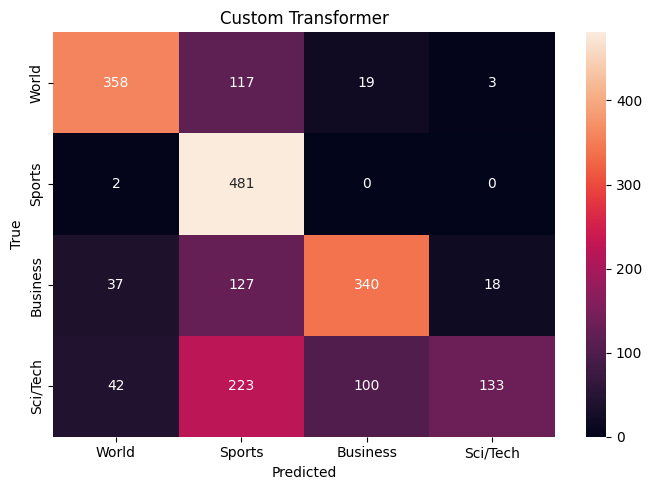

In [7]:
# ============================================================
# 6. Custom Transformer Encoder
# ============================================================
class TransformerBlock(layers.Layer):
    def __init__(
        self,
        embed_dim=128,
        num_heads=4,
        ff_dim=256,
        rate=0.1,
    ):
        super().__init__()

        self.att = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim // num_heads,
        )

        self.ffn = tf.keras.Sequential([
            layers.Dense(
                ff_dim,
                activation="gelu",
            ),
            layers.Dense(embed_dim),
        ])

        self.norm1 = layers.LayerNormalization()
        self.norm2 = layers.LayerNormalization()

        self.drop1 = layers.Dropout(rate)
        self.drop2 = layers.Dropout(rate)

    def call(self, x, training=False):
        attention = self.att(
            x,
            x,
            training=training,
        )

        x = self.norm1(
            x + self.drop1(
                attention,
                training=training,
            )
        )

        ffn_output = self.ffn(
            x,
            training=training,
        )

        return self.norm2(
            x + self.drop2(
                ffn_output,
                training=training,
            )
        )


inp = layers.Input(
    shape=(MAX_LEN,),
    dtype=tf.int32,
)

x = layers.Embedding(
    VOCAB_SIZE,
    128,
)(inp)

x = TransformerBlock()(x)
x = TransformerBlock()(x)

x = layers.GlobalAveragePooling1D()(x)
x = layers.Dropout(0.2)(x)

out = layers.Dense(NUM_LABELS)(x)

transformer_model = Model(
    inp,
    out,
)

transformer_model.compile(
    optimizer=tf.keras.optimizers.Adam(2e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(
        from_logits=True
    ),
    metrics=["accuracy"],
)

transformer_history = transformer_model.fit(
    X_train,
    train_df["label"].values,
    validation_data=(
        X_val,
        val_df["label"].values,
    ),
    epochs=EPOCHS,
    batch_size=64,
    verbose=1,
)

transformer_logits = transformer_model.predict(
    X_test,
    batch_size=64,
    verbose=1,
)

transformer_prob = tf.nn.softmax(
    transformer_logits,
    axis=-1,
).numpy()

transformer_pred = transformer_prob.argmax(axis=1)

probabilities["Custom Transformer"] = transformer_prob

results.append(
    evaluate_predictions(
        test_df["label"],
        transformer_pred,
        transformer_prob,
        "Custom Transformer",
    )
)

plot_confusion(
    test_df["label"],
    transformer_pred,
    "Custom Transformer",
)

# 5. Hugging Face Sequence Classification

BERT, BART and GPT-2 use `AutoModelForSequenceClassification`.

Important compatibility fixes:
1. `Trainer(..., processing_class=tokenizer)` instead of the removed/unsupported `tokenizer=...` argument.
2. GPT-2 receives `pad_token = eos_token`.
3. `trainer.predict()` output is normalized safely before softmax.
4. A 4-class `id2label`/`label2id` mapping is supplied explicitly.

In [8]:
# ============================================================
# 7. Convert pandas dataframes to Hugging Face datasets
# ============================================================
def make_hf_dataset(df):
    return Dataset.from_pandas(
        df[["text", "label"]].reset_index(drop=True),
        preserve_index=False,
    )

hf_train = make_hf_dataset(train_df)
hf_val = make_hf_dataset(val_df)
hf_test = make_hf_dataset(test_df)

print(hf_train)
print(hf_val)
print(hf_test)

Dataset({
    features: ['text', 'label'],
    num_rows: 6000
})
Dataset({
    features: ['text', 'label'],
    num_rows: 1000
})
Dataset({
    features: ['text', 'label'],
    num_rows: 2000
})


In [9]:
# ============================================================
# 8. Robust HF sequence-classification trainer
# ============================================================
def train_hf_classifier(
    checkpoint,
    model_name,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
):
    print(f"\n{'='*70}")
    print(f"Training: {model_name}")
    print(f"Checkpoint: {checkpoint}")
    print(f"{'='*70}")

    tokenizer = AutoTokenizer.from_pretrained(
        checkpoint,
        use_fast=True,
    )

    # GPT-2 has no pad token in its original tokenizer.
    if tokenizer.pad_token is None:
        if tokenizer.eos_token is not None:
            tokenizer.pad_token = tokenizer.eos_token
        else:
            tokenizer.add_special_tokens(
                {"pad_token": "[PAD]"}
            )

    def tokenize_batch(batch):
        return tokenizer(
            batch["text"],
            truncation=True,
            max_length=MAX_LEN,
        )

    tr = hf_train.map(
        tokenize_batch,
        batched=True,
        remove_columns=["text"],
        desc=f"Tokenizing train: {model_name}",
    )

    va = hf_val.map(
        tokenize_batch,
        batched=True,
        remove_columns=["text"],
        desc=f"Tokenizing validation: {model_name}",
    )

    te = hf_test.map(
        tokenize_batch,
        batched=True,
        remove_columns=["text"],
        desc=f"Tokenizing test: {model_name}",
    )

    id2label = {
        0: "World",
        1: "Sports",
        2: "Business",
        3: "Sci/Tech",
    }

    label2id = {
        "World": 0,
        "Sports": 1,
        "Business": 2,
        "Sci/Tech": 3,
    }

    model = AutoModelForSequenceClassification.from_pretrained(
        checkpoint,
        num_labels=NUM_LABELS,
        id2label=id2label,
        label2id=label2id,
        ignore_mismatched_sizes=True,
    )

    # Necessary for GPT-2-style causal models used for classification.
    model.config.pad_token_id = tokenizer.pad_token_id

    # If a newly-added token changed the tokenizer vocabulary,
    # resize the model embeddings safely.
    if len(tokenizer) != model.get_input_embeddings().num_embeddings:
        model.resize_token_embeddings(len(tokenizer))

    data_collator = DataCollatorWithPadding(
        tokenizer=tokenizer,
    )

    def compute_metrics(eval_pred):
        logits = eval_pred.predictions

        # Some architectures/versions can return a tuple.
        if isinstance(logits, tuple):
            logits = logits[0]

        logits = np.asarray(logits)

        pred = np.argmax(
            logits,
            axis=-1,
        )

        return {
            "accuracy": accuracy_score(
                eval_pred.label_ids,
                pred,
            )
        }

    args = TrainingArguments(
        output_dir=f"./models/{model_name}",
        learning_rate=lr,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        num_train_epochs=epochs,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="accuracy",
        greater_is_better=True,
        report_to="none",
        fp16=torch.cuda.is_available(),
        save_total_limit=1,
        logging_steps=50,
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=tr,
        eval_dataset=va,

        # FIX for the user's Trainer tokenizer error
        processing_class=tokenizer,

        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

    trainer.train()

    # ========================================================
    # Test prediction
    # ========================================================
    prediction_output = trainer.predict(te)
    raw_predictions = prediction_output.predictions

    # FIX for BART/GPT-style tuple prediction outputs
    if isinstance(raw_predictions, tuple):
        raw_predictions = raw_predictions[0]

    logits = np.asarray(
        raw_predictions,
        dtype=np.float32,
    )

    if logits.ndim != 2 or logits.shape[-1] != NUM_LABELS:
        raise ValueError(
            f"{model_name}: unexpected prediction shape "
            f"{logits.shape}. Expected "
            f"(n_samples, {NUM_LABELS})."
        )

    # Numerically stable softmax
    logits = logits - logits.max(
        axis=-1,
        keepdims=True,
    )

    exp_logits = np.exp(logits)

    prob = exp_logits / exp_logits.sum(
        axis=-1,
        keepdims=True,
    )

    yhat = prob.argmax(axis=1)

    probabilities[model_name] = prob

    result = evaluate_predictions(
        test_df["label"].to_numpy(),
        yhat,
        prob,
        model_name,
    )

    results.append(result)

    plot_confusion(
        test_df["label"].to_numpy(),
        yhat,
        model_name,
    )

    return trainer, tokenizer

# 6. BERT


Training: BERT_AGNews
Checkpoint: bert-base-uncased


Tokenizing train: BERT_AGNews:   0%|          | 0/6000 [00:00<?, ? examples/s]

Tokenizing validation: BERT_AGNews:   0%|          | 0/1000 [00:00<?, ? examples/s]

Tokenizing test: BERT_AGNews:   0%|          | 0/2000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.289655,0.280010,0.917000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte


===== BERT_AGNews =====
              precision    recall  f1-score   support

       World       0.95      0.87      0.91       497
      Sports       0.95      0.99      0.97       483
    Business       0.89      0.83      0.86       522
    Sci/Tech       0.83      0.92      0.87       498

    accuracy                           0.90      2000
   macro avg       0.90      0.90      0.90      2000
weighted avg       0.90      0.90      0.90      2000

Metrics: {'model': 'BERT_AGNews', 'accuracy': 0.9015, 'precision': 0.903678371529476, 'recall': 0.9015, 'f1': 0.9012166367402221, 'auc_ovr': 0.9778106280902267}


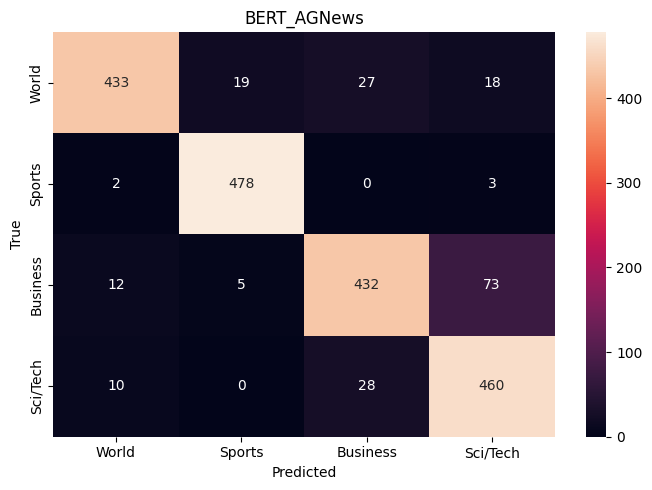

In [10]:
# ============================================================
# 9. BERT
# ============================================================
bert_trainer, bert_tokenizer = train_hf_classifier(
    "bert-base-uncased",
    "BERT_AGNews",
    epochs=EPOCHS,
    lr=2e-5,
)

# 7. BART

BART's classification head is created for the 4 AG News labels. The `MISSING` classification-head message from the pretrained base checkpoint is expected because the AG News classifier is task-specific and must be learned.


Training: BART_AGNews
Checkpoint: facebook/bart-base


Tokenizing train: BART_AGNews:   0%|          | 0/6000 [00:00<?, ? examples/s]

Tokenizing validation: BART_AGNews:   0%|          | 0/1000 [00:00<?, ? examples/s]

Tokenizing test: BART_AGNews:   0%|          | 0/2000 [00:00<?, ? examples/s]

[transformers] You passed `num_labels=4` which is incompatible to the `id2label` map of length `3`.


...

[transformers] BartForSequenceClassification LOAD REPORT from: facebook/bart-base
Key                                 | Status  | 
------------------------------------+---------+-
classification_head.out_proj.bias   | MISSING | 
classification_head.out_proj.weight | MISSING | 
classification_head.dense.bias      | MISSING | 
classification_head.dense.weight    | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.299233,0.260526,0.918000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.decoder.embed_tokens.weight'].



===== BART_AGNews =====
              precision    recall  f1-score   support

       World       0.93      0.89      0.91       497
      Sports       0.96      0.99      0.97       483
    Business       0.90      0.84      0.87       522
    Sci/Tech       0.85      0.92      0.88       498

    accuracy                           0.91      2000
   macro avg       0.91      0.91      0.91      2000
weighted avg       0.91      0.91      0.91      2000

Metrics: {'model': 'BART_AGNews', 'accuracy': 0.906, 'precision': 0.906992444052967, 'recall': 0.906, 'f1': 0.9056781163602049, 'auc_ovr': 0.9810500042816661}


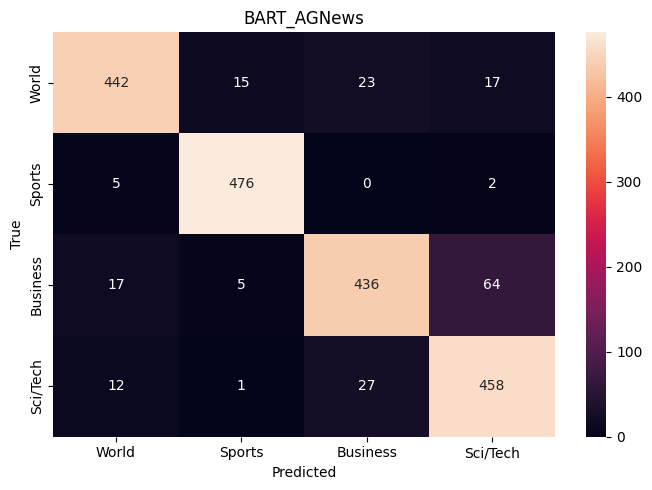

In [11]:
# ============================================================
# 10. BART
# ============================================================
bart_trainer, bart_tokenizer = train_hf_classifier(
    "facebook/bart-base",
    "BART_AGNews",
    epochs=EPOCHS,
    lr=2e-5,
)

# 8. GPT-2 family

GPT-2 is adapted to sequence classification. The key compatibility fix is defining a padding token before creating the data collator and model configuration.


Training: GPT2_AGNews
Checkpoint: gpt2


Tokenizing train: GPT2_AGNews:   0%|          | 0/6000 [00:00<?, ? examples/s]

Tokenizing validation: GPT2_AGNews:   0%|          | 0/1000 [00:00<?, ? examples/s]

Tokenizing test: GPT2_AGNews:   0%|          | 0/2000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] GPT2ForSequenceClassification LOAD REPORT from: gpt2
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.326942,0.328678,0.894000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


===== GPT2_AGNews =====
              precision    recall  f1-score   support

       World       0.91      0.87      0.89       497
      Sports       0.94      0.99      0.97       483
    Business       0.85      0.82      0.83       522
    Sci/Tech       0.83      0.86      0.84       498

    accuracy                           0.88      2000
   macro avg       0.88      0.88      0.88      2000
weighted avg       0.88      0.88      0.88      2000

Metrics: {'model': 'GPT2_AGNews', 'accuracy': 0.882, 'precision': 0.8816295679332972, 'recall': 0.882, 'f1': 0.8814473050145635, 'auc_ovr': 0.9734973497174668}


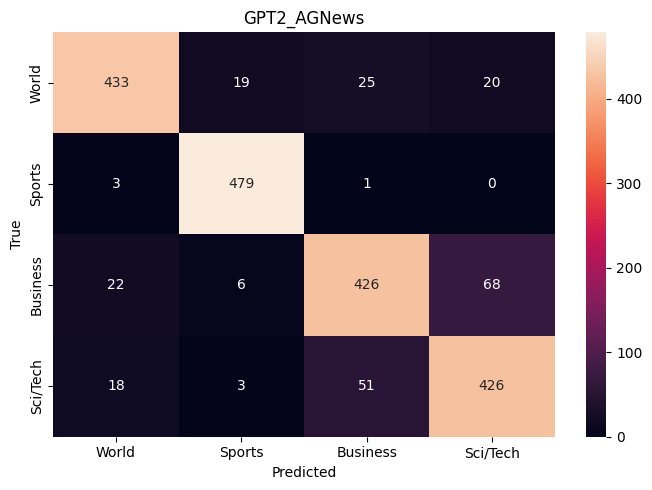

In [12]:
# ============================================================
# 11. GPT-2
# ============================================================
gpt_trainer, gpt_tokenizer = train_hf_classifier(
    "gpt2",
    "GPT2_AGNews",
    epochs=EPOCHS,
    lr=2e-5,
)

# 9. T5 — Text-to-Text Classification

T5 is not treated as a normal `AutoModelForSequenceClassification`.

Instead:

`classify news: <article>` → `world / sports / business / sci_tech`

A dedicated `Seq2SeqTrainer` is used.

In [13]:
# ============================================================
# 12. T5 dataset preparation
# ============================================================
T5_CHECKPOINT = "t5-small"

t5_tokenizer = T5Tokenizer.from_pretrained(
    T5_CHECKPOINT,
)

def make_t5_dataset(df):
    return Dataset.from_pandas(
        pd.DataFrame({
            "text": df["text"].astype(str).values,
            "label_text": [
                LABEL_WORDS[int(y)]
                for y in df["label"].values
            ],
        }),
        preserve_index=False,
    )

t5_train = make_t5_dataset(train_df)
t5_val = make_t5_dataset(val_df)
t5_test = make_t5_dataset(test_df)

t5_model = T5ForConditionalGeneration.from_pretrained(
    T5_CHECKPOINT,
)

print(t5_train)

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Dataset({
    features: ['text', 'label_text'],
    num_rows: 6000
})


In [14]:
# ============================================================
# 13. Tokenize T5 source and target text
# ============================================================
def t5_preprocess(batch):
    inputs = [
        "classify news: " + text
        for text in batch["text"]
    ]

    model_inputs = t5_tokenizer(
        inputs,
        max_length=MAX_LEN,
        truncation=True,
    )

    labels = t5_tokenizer(
        text_target=batch["label_text"],
        max_length=8,
        truncation=True,
    )

    model_inputs["labels"] = labels["input_ids"]

    return model_inputs


t5_train_tok = t5_train.map(
    t5_preprocess,
    batched=True,
    remove_columns=t5_train.column_names,
    desc="Tokenizing T5 train",
)

t5_val_tok = t5_val.map(
    t5_preprocess,
    batched=True,
    remove_columns=t5_val.column_names,
    desc="Tokenizing T5 validation",
)

t5_test_tok = t5_test.map(
    t5_preprocess,
    batched=True,
    remove_columns=t5_test.column_names,
    desc="Tokenizing T5 test",
)

t5_collator = DataCollatorForSeq2Seq(
    tokenizer=t5_tokenizer,
    model=t5_model,
)

Tokenizing T5 train:   0%|          | 0/6000 [00:00<?, ? examples/s]

Tokenizing T5 validation:   0%|          | 0/1000 [00:00<?, ? examples/s]

Tokenizing T5 test:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [15]:
# ============================================================
# 14. Train T5 with Seq2SeqTrainer
# ============================================================
def normalize_t5_label(text):
    text = text.strip().lower()

    aliases = {
        "world": 0,
        "sports": 1,
        "business": 2,
        "sci_tech": 3,
        "sci/tech": 3,
        "science/technology": 3,
        "science and technology": 3,
    }

    return aliases.get(text, -1)


def t5_compute_metrics(eval_pred):
    predictions, labels = eval_pred

    if isinstance(predictions, tuple):
        predictions = predictions[0]

    predictions = np.asarray(predictions)

    pred_text = t5_tokenizer.batch_decode(
        predictions,
        skip_special_tokens=True,
    )

    labels = np.where(
        labels != -100,
        labels,
        t5_tokenizer.pad_token_id,
    )

    true_text = t5_tokenizer.batch_decode(
        labels,
        skip_special_tokens=True,
    )

    y_pred = np.array([
        normalize_t5_label(x)
        for x in pred_text
    ])

    y_true = np.array([
        normalize_t5_label(x)
        for x in true_text
    ])

    valid = (
        (y_true >= 0)
        & (y_pred >= 0)
    )

    accuracy = (
        accuracy_score(
            y_true[valid],
            y_pred[valid],
        )
        if valid.any()
        else 0.0
    )

    return {
        "accuracy": float(accuracy),
    }


t5_args = Seq2SeqTrainingArguments(
    output_dir="./models/T5_AGNews",
    learning_rate=3e-4,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=EPOCHS,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
    predict_with_generate=True,
    generation_max_length=8,
    report_to="none",
    fp16=torch.cuda.is_available(),
    save_total_limit=1,
    logging_steps=50,
)

t5_trainer = Seq2SeqTrainer(
    model=t5_model,
    args=t5_args,
    train_dataset=t5_train_tok,
    eval_dataset=t5_val_tok,
    processing_class=t5_tokenizer,
    data_collator=t5_collator,
    compute_metrics=t5_compute_metrics,
)

t5_trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.133228,0.123086,0.903000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight', 'lm_head.weight'].


TrainOutput(global_step=750, training_loss=0.36107859230041506, metrics={'train_runtime': 128.0629, 'train_samples_per_second': 46.852, 'train_steps_per_second': 5.856, 'total_flos': 147924359577600.0, 'train_loss': 0.36107859230041506, 'epoch': 1.0})

First 20 T5 predictions:
True=Sports     | Generated='sports' | Pred=Sports
True=Business   | Generated='business' | Pred=Business
True=Sports     | Generated='sports' | Pred=Sports
True=Business   | Generated='business' | Pred=Business
True=Sci/Tech   | Generated='sci_tech' | Pred=Sci/Tech
True=World      | Generated='business' | Pred=Business
True=Business   | Generated='business' | Pred=Business
True=Business   | Generated='business' | Pred=Business
True=Sci/Tech   | Generated='sci_tech' | Pred=Sci/Tech
True=Business   | Generated='sci_tech' | Pred=Sci/Tech
True=World      | Generated='world' | Pred=World
True=Sports     | Generated='sports' | Pred=Sports
True=Sports     | Generated='sports' | Pred=Sports
True=World      | Generated='world' | Pred=World
True=Business   | Generated='business' | Pred=Business
True=Sci/Tech   | Generated='sci_tech' | Pred=Sci/Tech
True=World      | Generated='sci_tech' | Pred=Sci/Tech
True=Sports     | Generated='sports' | Pred=Sports
True=World      |

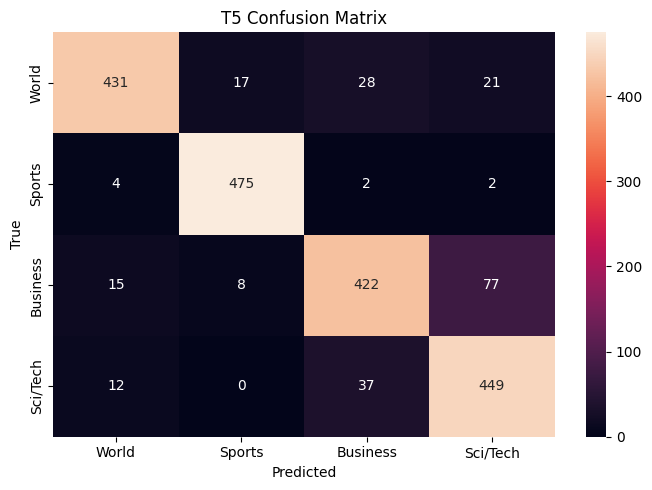

In [16]:
# ============================================================
# 15. T5 test evaluation
# ============================================================
t5_prediction = t5_trainer.predict(
    t5_test_tok,
    max_length=8,
)

t5_generated = t5_prediction.predictions

if isinstance(t5_generated, tuple):
    t5_generated = t5_generated[0]

t5_generated = np.asarray(t5_generated)

t5_text = t5_tokenizer.batch_decode(
    t5_generated,
    skip_special_tokens=True,
)

t5_pred = np.array([
    normalize_t5_label(x)
    for x in t5_text
])

t5_true = test_df["label"].to_numpy()

print("First 20 T5 predictions:")
for i in range(min(20, len(t5_text))):
    print(
        f"True={LABEL_NAMES[t5_true[i]]:10s} | "
        f"Generated={t5_text[i]!r} | "
        f"Pred={LABEL_NAMES[t5_pred[i]] if t5_pred[i] >= 0 else 'Unknown'}"
    )

valid = t5_pred >= 0

if valid.any():
    t5_result = evaluate_predictions(
        t5_true[valid],
        t5_pred[valid],
        y_prob=None,
        model_name="T5",
    )
else:
    t5_result = {
        "model": "T5",
        "accuracy": 0.0,
        "precision": 0.0,
        "recall": 0.0,
        "f1": 0.0,
        "auc_ovr": np.nan,
    }
    print("T5 produced no recognized labels.")

results.append(t5_result)

if valid.any():
    plot_confusion(
        t5_true[valid],
        t5_pred[valid],
        "T5 Confusion Matrix",
    )

# 10. Unified model comparison

,model,accuracy,precision,recall,f1,auc_ovr
0,BART_AGNews,0.9060,0.906992,0.9060,0.905678,0.981050
1,BERT_AGNews,0.9015,0.903678,0.9015,0.901217,0.977811
2,T5,0.8885,0.890135,0.8885,0.888209,NaN
3,GPT2_AGNews,0.8820,0.881630,0.8820,0.881447,0.973497
4,BiLSTM + Attention,0.8420,0.848273,0.8420,0.841897,0.962399
5,Custom Transformer,0.6560,0.733561,0.6560,0.634945,0.927610


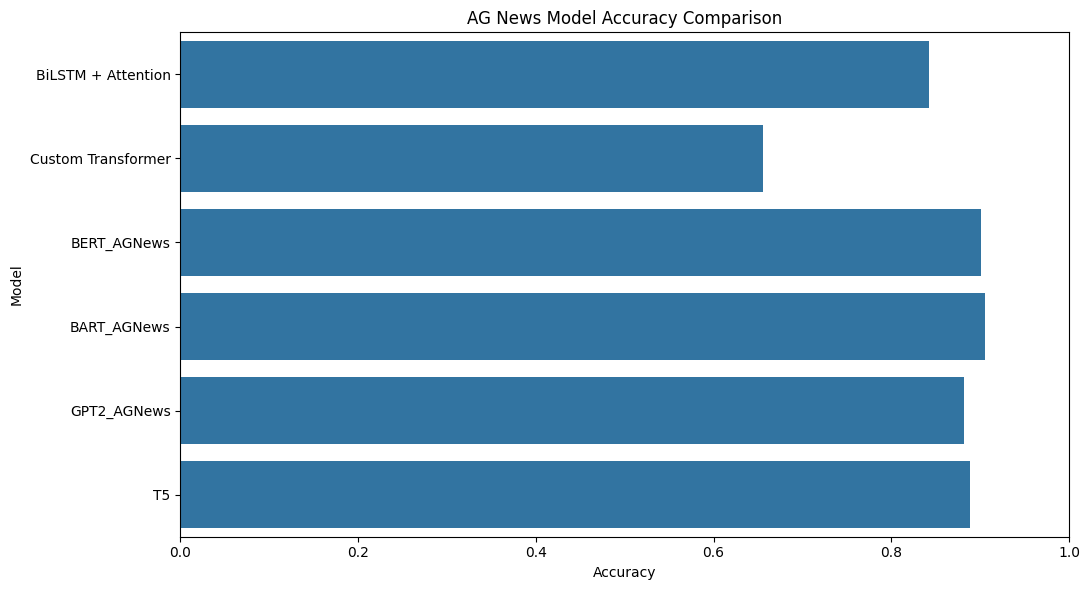

,model,accuracy,precision,recall,f1,auc_ovr
0,BiLSTM + Attention,0.8420,0.848273,0.8420,0.841897,0.962399
1,Custom Transformer,0.6560,0.733561,0.6560,0.634945,0.927610
2,BERT_AGNews,0.9015,0.903678,0.9015,0.901217,0.977811
3,BART_AGNews,0.9060,0.906992,0.9060,0.905678,0.981050
4,GPT2_AGNews,0.8820,0.881630,0.8820,0.881447,0.973497
5,T5,0.8885,0.890135,0.8885,0.888209,NaN


In [17]:
# ============================================================
# 16. Comparison table
# ============================================================
results_df = pd.DataFrame(results)

display(
    results_df.sort_values(
        "accuracy",
        ascending=False,
    ).reset_index(drop=True)
)

metrics_cols = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "auc_ovr",
]

plt.figure(figsize=(11, 6))
sns.barplot(
    data=results_df,
    x="accuracy",
    y="model",
)
plt.xlim(0, 1)
plt.xlabel("Accuracy")
plt.ylabel("Model")
plt.title("AG News Model Accuracy Comparison")
plt.tight_layout()
plt.show()

display(
    results_df[
        ["model"]
        + [
            c
            for c in metrics_cols
            if c in results_df.columns
        ]
    ]
)


ROC curves: BiLSTM + Attention


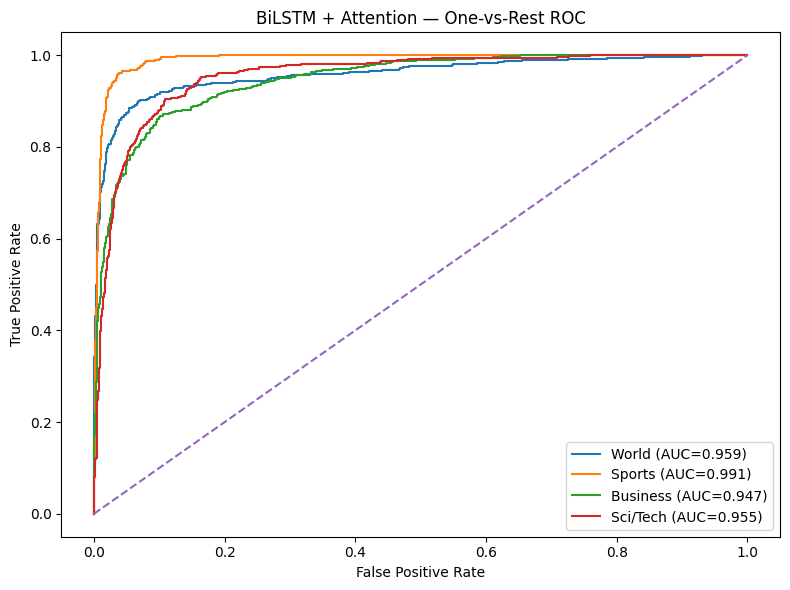


ROC curves: Custom Transformer


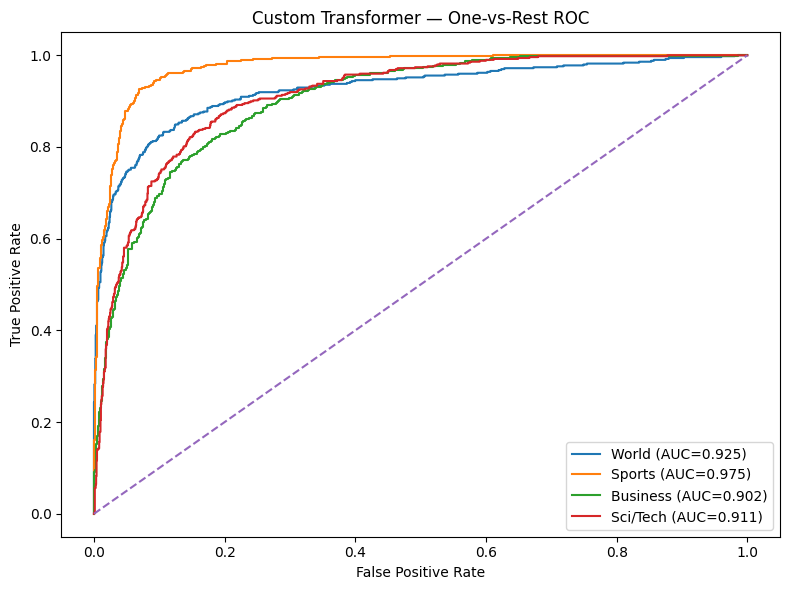


ROC curves: BERT_AGNews


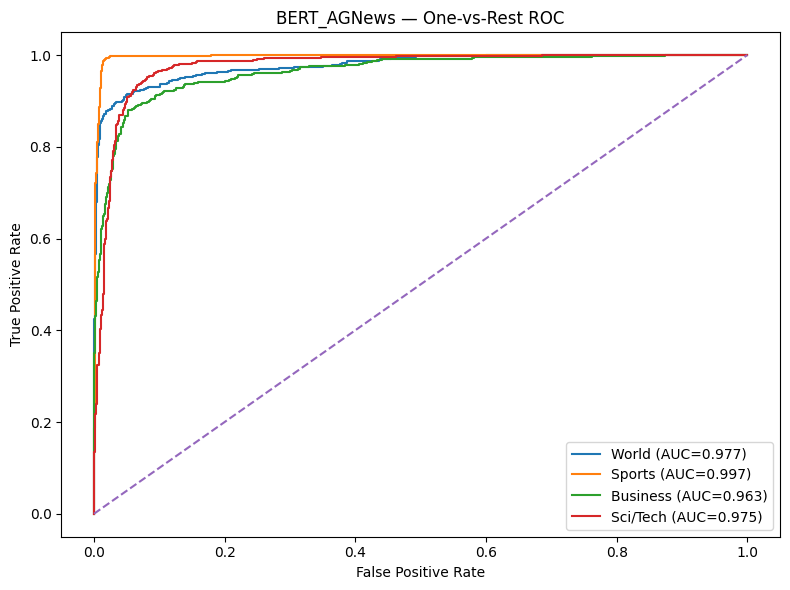


ROC curves: BART_AGNews


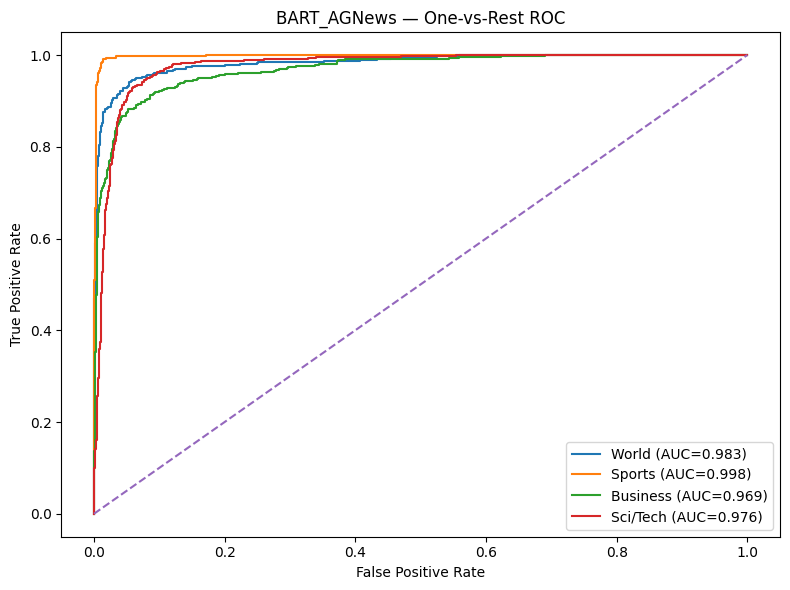


ROC curves: GPT2_AGNews


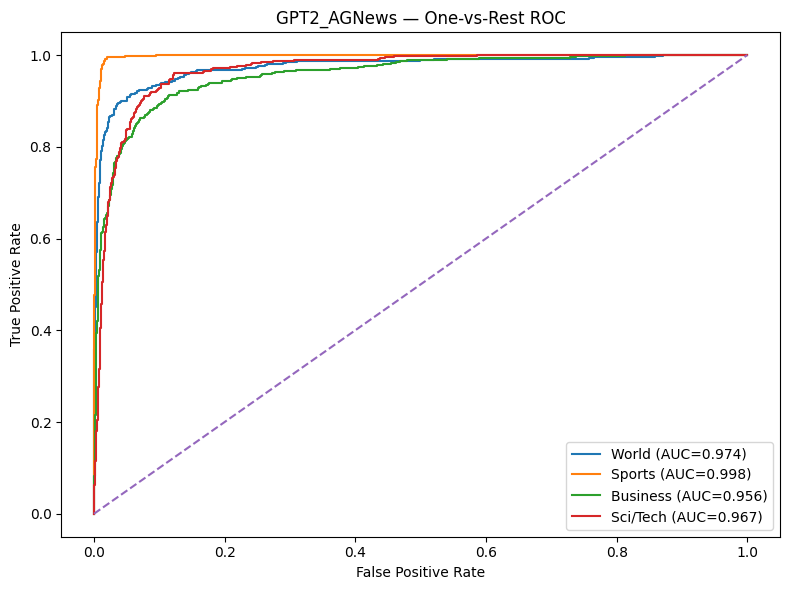

In [18]:
# ============================================================
# 17. ROC/AUC for models with class probabilities
# ============================================================
for model_name, y_prob in probabilities.items():
    print(f"\nROC curves: {model_name}")
    plot_multiclass_roc(
        test_df["label"].to_numpy(),
        y_prob,
        f"{model_name} — One-vs-Rest ROC",
    )

# 11. Training history visualization

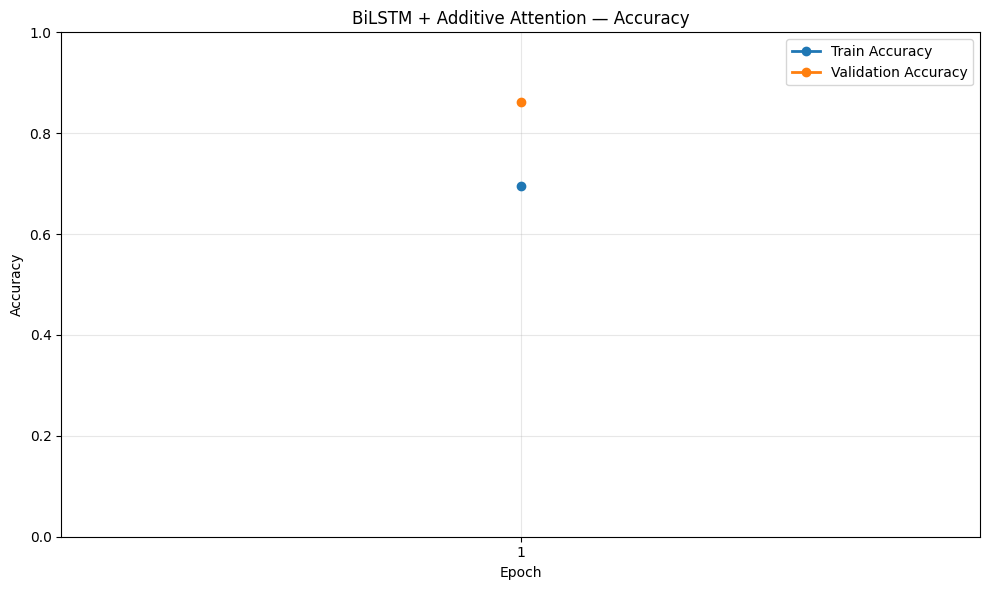

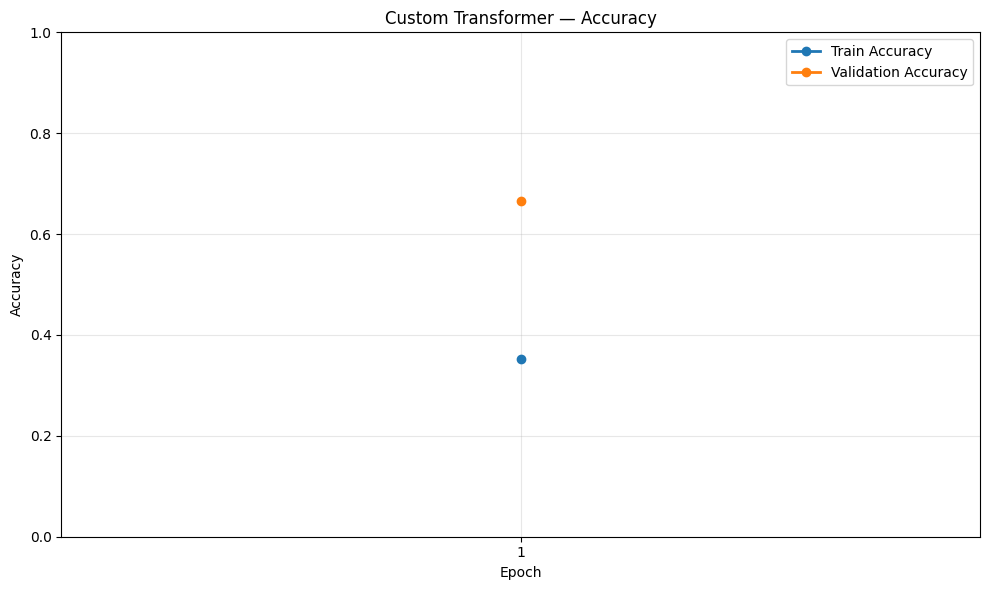

In [26]:
# ============================================================
# Custom Model Training History Visualization
# ============================================================

# -------------------------------
# 1. BiLSTM + Attention
# -------------------------------
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(attn_history.history["accuracy"]) + 1),
    attn_history.history["accuracy"],
    marker="o",
    linewidth=2,
    label="Train Accuracy"
)

plt.plot(
    range(1, len(attn_history.history["val_accuracy"]) + 1),
    attn_history.history["val_accuracy"],
    marker="o",
    linewidth=2,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("BiLSTM + Additive Attention — Accuracy")

plt.xticks(
    range(1, len(attn_history.history["accuracy"]) + 1)
)

plt.ylim(0, 1.0)
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()


# -------------------------------
# 2. Custom Transformer
# -------------------------------
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(transformer_history.history["accuracy"]) + 1),
    transformer_history.history["accuracy"],
    marker="o",
    linewidth=2,
    label="Train Accuracy"
)

plt.plot(
    range(1, len(transformer_history.history["val_accuracy"]) + 1),
    transformer_history.history["val_accuracy"],
    marker="o",
    linewidth=2,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Custom Transformer — Accuracy")

plt.xticks(
    range(1, len(transformer_history.history["accuracy"]) + 1)
)

plt.ylim(0, 1.0)
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

# 12. Save all successful model artifacts

The previous notebook failed here because `bert_trainer` did not exist after BERT training crashed.

This version checks whether each model was successfully created before saving it.

In [20]:
# ============================================================
# 19. Save artifacts safely
# ============================================================
os.makedirs("models", exist_ok=True)

# Custom TensorFlow models
if "attn_model" in globals():
    attn_model.save_weights(
        "models/bilstm_attention.weights.h5"
    )
    print("Saved BiLSTM + Attention weights.")

if "transformer_model" in globals():
    transformer_model.save_weights(
        "models/custom_transformer.weights.h5"
    )
    print("Saved Custom Transformer weights.")

# Hugging Face models
if "bert_trainer" in globals():
    bert_trainer.save_model(
        "models/BERT_AGNews"
    )
    bert_tokenizer.save_pretrained(
        "models/BERT_AGNews"
    )
    print("Saved BERT.")

if "bart_trainer" in globals():
    bart_trainer.save_model(
        "models/BART_AGNews"
    )
    bart_tokenizer.save_pretrained(
        "models/BART_AGNews"
    )
    print("Saved BART.")

if "gpt_trainer" in globals():
    gpt_trainer.save_model(
        "models/GPT2_AGNews"
    )
    gpt_tokenizer.save_pretrained(
        "models/GPT2_AGNews"
    )
    print("Saved GPT-2.")

if "t5_trainer" in globals():
    t5_trainer.save_model(
        "models/T5_AGNews"
    )
    t5_tokenizer.save_pretrained(
        "models/T5_AGNews"
    )
    print("Saved T5.")

# Save metrics
results_df.to_csv(
    "models/model_comparison.csv",
    index=False,
)

print("\nAll available artifacts have been saved.")

Saved BiLSTM + Attention weights.
Saved Custom Transformer weights.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved BERT.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved BART.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved GPT-2.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved T5.

All available artifacts have been saved.


# 13. Single-text inference

For BERT/BART/GPT-2, the helper below works with the saved/in-memory `Trainer` objects.

T5 uses text-to-text generation separately.

In [21]:
# ============================================================
# 20. HF classifier inference helper
# ============================================================
def predict_hf_text(
    trainer,
    tokenizer,
    text,
):
    encoded = tokenizer(
        text,
        truncation=True,
        max_length=MAX_LEN,
        return_tensors="pt",
    )

    model = trainer.model
    model.eval()

    encoded = {
        k: v.to(model.device)
        for k, v in encoded.items()
    }

    with torch.no_grad():
        output = model(**encoded)

    logits = output.logits

    prob = torch.softmax(
        logits,
        dim=-1,
    )[0].cpu().numpy()

    idx = int(prob.argmax())

    return LABEL_NAMES[idx], float(prob[idx])


example_texts = [
    "The team won the championship after a dramatic final match.",
    "The central bank announced a new economic policy.",
    "A new semiconductor technology was unveiled by researchers.",
    "World leaders met to discuss an international agreement.",
]

if "bert_trainer" in globals():
    print("\nBERT predictions:")
    for text in example_texts:
        print(text)
        print(
            "Prediction:",
            predict_hf_text(
                bert_trainer,
                bert_tokenizer,
                text,
            ),
        )

if "bart_trainer" in globals():
    print("\nBART predictions:")
    for text in example_texts:
        print(text)
        print(
            "Prediction:",
            predict_hf_text(
                bart_trainer,
                bart_tokenizer,
                text,
            ),
        )

if "gpt_trainer" in globals():
    print("\nGPT-2 predictions:")
    for text in example_texts:
        print(text)
        print(
            "Prediction:",
            predict_hf_text(
                gpt_trainer,
                gpt_tokenizer,
                text,
            ),
        )


BERT predictions:
The team won the championship after a dramatic final match.
Prediction: ('Sports', 0.9762917160987854)
The central bank announced a new economic policy.
Prediction: ('Business', 0.8972083926200867)
A new semiconductor technology was unveiled by researchers.
Prediction: ('Sci/Tech', 0.9509906768798828)
World leaders met to discuss an international agreement.
Prediction: ('World', 0.9494761228561401)

BART predictions:
The team won the championship after a dramatic final match.
Prediction: ('Sports', 0.9921965599060059)
The central bank announced a new economic policy.
Prediction: ('Business', 0.96356201171875)
A new semiconductor technology was unveiled by researchers.
Prediction: ('Sci/Tech', 0.9825037121772766)
World leaders met to discuss an international agreement.
Prediction: ('World', 0.9815049767494202)

GPT-2 predictions:
The team won the championship after a dramatic final match.
Prediction: ('Sports', 0.9883308410644531)
The central bank announced a new econ

In [22]:
# ============================================================
# 21. T5 single-text inference
# ============================================================
def predict_t5_text(text):
    prompt = "classify news: " + text

    enc = t5_tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LEN,
    )

    enc = {
        k: v.to(t5_trainer.model.device)
        for k, v in enc.items()
    }

    with torch.no_grad():
        generated = t5_trainer.model.generate(
            **enc,
            max_new_tokens=8,
        )

    generated_text = t5_tokenizer.decode(
        generated[0],
        skip_special_tokens=True,
    ).strip()

    idx = normalize_t5_label(
        generated_text
    )

    label = (
        LABEL_NAMES[idx]
        if idx >= 0
        else "Unknown"
    )

    return label, generated_text


if "t5_trainer" in globals():
    print("\nT5 predictions:")
    for text in example_texts:
        print(text)
        print(
            "Prediction:",
            predict_t5_text(text),
        )

[transformers] Both `max_new_tokens` (=8) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=8) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=8) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



T5 predictions:
The team won the championship after a dramatic final match.
Prediction: ('Sports', 'sports')
The central bank announced a new economic policy.
Prediction: ('Business', 'business')
A new semiconductor technology was unveiled by researchers.


[transformers] Both `max_new_tokens` (=8) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Prediction: ('Sci/Tech', 'sci_tech')
World leaders met to discuss an international agreement.
Prediction: ('World', 'world')


# 14. Final checklist

### Errors fixed
- `Trainer.__init__() got an unexpected keyword argument 'tokenizer'`
- BART `num_labels=4` / label-map mismatch
- BART `classification_head.* MISSING` confusion
- BART/GPT `predictions` tuple → array conversion issue
- GPT-2 missing `pad_token`
- T5 incorrectly handled as a normal classifier
- Save-cell `NameError` when a previous model failed
- Keras AdditiveAttention mask warning

### Recommended run
For a first test, keep:
- `TRAIN_SAMPLES = 7000`
- `VAL_SAMPLES = 1000`
- `TEST_SAMPLES = 2000`
- `EPOCHS = 1`

After the notebook runs successfully on GPU, increase `EPOCHS` to 2–4 and/or use more training samples.